In [1]:
# import packages
import os
import pyproj
# pyproj.datadir.set_data_dir('/srv/conda/envs/mintpy/share/proj')
# os.environ["PROJ_DATA"]="/srv/conda/envs/mintpy/share/proj"
from glob import glob
import geopandas as gpd
from pathlib import Path
from typing import List, Union
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
import xarray as xr
import rasterio as rio
import pandas as pd
import seaborn as sns
from rasterio.enums import Resampling
sns.set_theme()

In [2]:
# set up paths, directories, and variables for this specific dam
data_path = '/home/jovyan/repos/fufiters_imja_analysis/data'
asc_burst = '012_023790_IW1'
des_burst = '121_258661_IW2'
asc_burst_path = f'{data_path}/data_igrams/{asc_burst}'
des_burst_path = f'{data_path}/data_igrams/{des_burst}'

dam_name = 'imja'
proc_path = f'/home/jovyan/repos/fufiters_imja_analysis/analysis'

# define reference point, [y, x]
reference_point = [3086715.2, 491092.4]

# define crs 
crs = 32645

In [3]:
# read in dam polygon
dam_fn = f'../mapping/polygons/{dam_name}_md.shp'
dam_gdf = gpd.read_file(dam_fn)
dam_gdf = dam_gdf.to_crs(crs) # reproject in case of mistake

# load in moving area polygon
moving_fn = f'../mapping/polygons/{dam_name}_moving.shp'
moving_gdf = gpd.read_file(moving_fn)

# load in moving area polygon
reference_fn = f'../mapping/polygons/{dam_name}_reference.shp'
reference_gdf = gpd.read_file(reference_fn)

# load in stable area polygon
stable_fn = f'../mapping/polygons/{dam_name}_stable.shp'
stable_gdf = gpd.read_file(stable_fn).to_crs(crs)

# load in water mask
water_fn = f'../mapping/polygons/water_mask.shp'
water_gdf = gpd.read_file(water_fn).to_crs(crs)

# pad dam bounds by 5 km 
padding = 5000
aoi_extent = [dam_gdf.bounds.minx.item()-padding,
               dam_gdf.bounds.maxy.item()+padding,
               dam_gdf.bounds.maxx.item()+padding,
               dam_gdf.bounds.miny.item()-padding]

In [23]:
dem_diff_fn = '20100221_mos_2m-tile-0_20190106_0749_102001007E1D1100_10200100820A5000_aligned_to_REFDEM_2.0m-DEM_20100221_mos_2m-tile-0_nuth_x+12.32_y+0.54_z+4.82_align_diff_rate_crop.tif'
diff_ds = rioxarray.open_rasterio(dem_diff_fn).squeeze()
diff_ds = diff_ds.where(diff_ds != -9999.)
diff_ds = diff_ds.rio.write_nodata(np.nan)

In [106]:
vertical_veloc_fn = 'vertical_velocity_imja.tif'
vertical_veloc = rioxarray.open_rasterio(vertical_veloc_fn).squeeze()

In [107]:
diff_rate_ds = diff_ds.rio.reproject_match(vertical_veloc, resampling=Resampling.bilinear)

In [108]:
vertical_moving = vertical_veloc.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)
dem_diff_moving = diff_rate_ds.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)

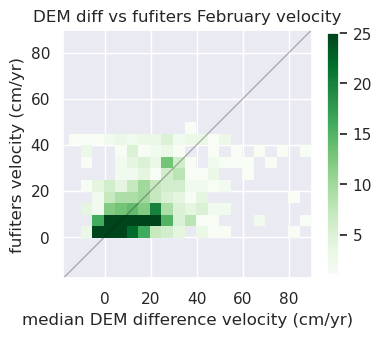

In [109]:
f, ax = plt.subplots(1, 1, figsize=(4, 4))
sns.histplot(ax=ax, x=(dem_diff_moving.values.ravel()*-100), y=(vertical_moving.values.ravel()*-100), 
                 cmap='Greens', cbar=True, alpha=1, binwidth=5, vmin=None, vmax=25, cbar_kws={'shrink':0.7})
ax.plot([-200, 200], [-200, 200], color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.set_title('DEM diff vs fufiters February velocity')
ax.set_ylabel('fufiters velocity (cm/yr)')
ax.set_xlabel('median DEM difference velocity (cm/yr)')
ax.set_box_aspect(1)
ax.set_xlim(-18, 90)
ax.set_ylim(-18, 90)
ax.set_xticks([0, 20,40,60,80])
f.tight_layout()

In [111]:
dem_diff_moving.mean()

<xarray.DataArray ()> Size: 8B
array(-0.16716624)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [110]:
vertical_moving.mean()

<xarray.DataArray ()> Size: 8B
array(-0.12988204)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

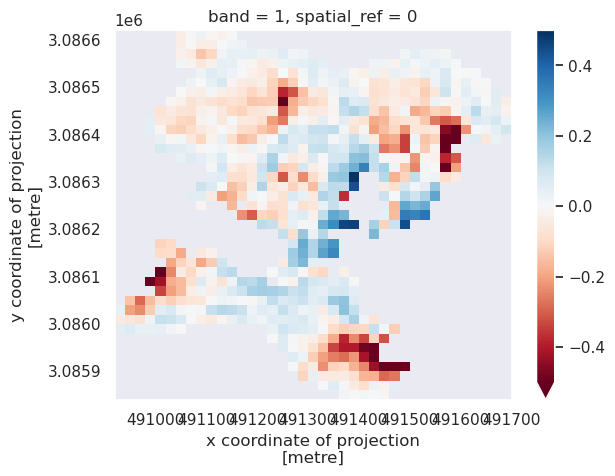

In [97]:
(dem_diff_moving - vertical_moving).plot(vmin=-0.5, vmax=0.5, cmap='RdBu')

Text(0.5, 0, 'error (m)')

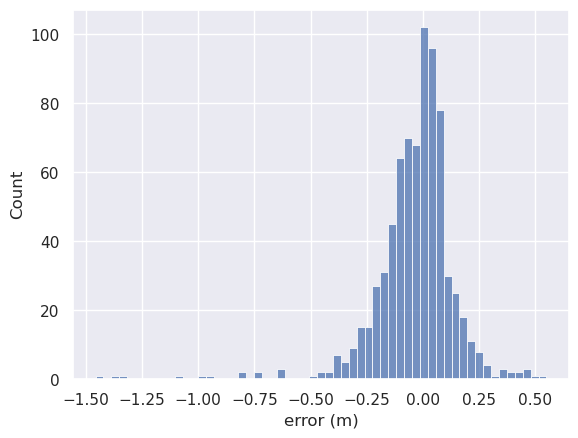

In [112]:
f, ax = plt.subplots()
sns.histplot((dem_diff_moving - vertical_moving).values.ravel(), ax=ax)
ax.set_xlabel('error (m)')

In [99]:
np.nanstd((dem_diff_moving - vertical_moving).values.ravel())

0.17359731483951146

In [92]:
vertical_moving.mean()

<xarray.DataArray ()> Size: 8B
array(-0.13932611)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [68]:
def calculate_r_squared(data1: xr.DataArray, data2: xr.DataArray) -> float:
    """
    Calculate the R-squared value between two 2D xarray DataArrays.

    Parameters:
    - data1 (xr.DataArray): The first 2D DataArray.
    - data2 (xr.DataArray): The second 2D DataArray.

    Returns:
    - float: The R-squared value.
    """
    # Ensure the datasets are aligned
    data1, data2 = xr.align(data1, data2, join="inner")
    
    # Flatten the data and remove NaN values
    data1_flat = data1.values.flatten()
    data2_flat = data2.values.flatten()
    
    # Mask out NaN values
    valid_mask = ~np.isnan(data1_flat) & ~np.isnan(data2_flat)
    data1_clean = data1_flat[valid_mask]
    data2_clean = data2_flat[valid_mask]
    
    # Check for sufficient data points
    if len(data1_clean) < 2 or len(data2_clean) < 2:
        raise ValueError("Insufficient valid data points to calculate R-squared.")
    
    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(data1_clean, data2_clean)
    r_squared = correlation_matrix[0, 1] ** 2
    
    return r_squared

In [71]:
import xarray as xr
import numpy as np

def calculate_rmse(data1: xr.DataArray, data2: xr.DataArray) -> float:
    """
    Calculate the Root Mean Square Error (RMSE) between two 2D xarray DataArrays.

    Parameters:
    - data1 (xr.DataArray): The first 2D DataArray.
    - data2 (xr.DataArray): The second 2D DataArray.

    Returns:
    - float: The RMSE value.
    """
    # Ensure the datasets are aligned
    data1, data2 = xr.align(data1, data2, join="inner")
    
    # Flatten the data and remove NaN values
    data1_flat = data1.values.flatten()
    data2_flat = data2.values.flatten()
    
    # Mask out NaN values
    valid_mask = ~np.isnan(data1_flat) & ~np.isnan(data2_flat)
    data1_clean = data1_flat[valid_mask]
    data2_clean = data2_flat[valid_mask]
    
    # Check for sufficient data points
    if len(data1_clean) < 1 or len(data2_clean) < 1:
        raise ValueError("Insufficient valid data points to calculate RMSE.")
    
    # Calculate RMSE
    mse = np.mean((data1_clean - data2_clean) ** 2)
    rmse = np.sqrt(mse)
    
    return rmse

In [100]:
calculate_r_squared(dem_diff_moving, vertical_moving)

0.163179899384723

In [101]:
calculate_rmse(dem_diff_moving, vertical_moving)

0.1753814717111709

## EW rate

In [36]:
dem_ew_fn = '20100221_0000_20190106_0000_vmap-F_vx.tif'
dem_ew_ds = rioxarray.open_rasterio(dem_ew_fn).squeeze()
dem_ew_ds = dem_ew_ds.where(dem_ew_ds != -9999.)
dem_ew_ds = dem_ew_ds.rio.write_nodata(np.nan)

In [37]:
ew_veloc_fn = 'ew_velocity_imja.tif'
ew_veloc = rioxarray.open_rasterio(ew_veloc_fn).squeeze()

In [38]:
dem_ew_ds = dem_ew_ds.rio.reproject_match(ew_veloc, resampling=Resampling.bilinear)

In [39]:
ew_moving = ew_veloc.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)
dem_ew_moving = dem_ew_ds.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)

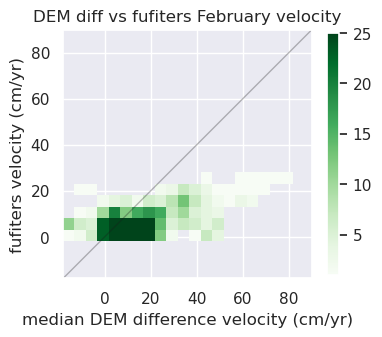

In [40]:
f, ax = plt.subplots(1, 1, figsize=(4, 4))
sns.histplot(ax=ax, x=(dem_ew_moving.values.ravel()*100), y=(ew_moving.values.ravel()*100), 
                 cmap='Greens', cbar=True, alpha=1, binwidth=5, vmin=None, vmax=25, cbar_kws={'shrink':0.7})
ax.plot([-200, 200], [-200, 200], color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.set_title('DEM diff vs fufiters February velocity')
ax.set_ylabel('fufiters velocity (cm/yr)')
ax.set_xlabel('median DEM difference velocity (cm/yr)')
ax.set_box_aspect(1)
ax.set_xlim(-18, 90)
ax.set_ylim(-18, 90)
ax.set_xticks([0, 20,40,60,80])
f.tight_layout()

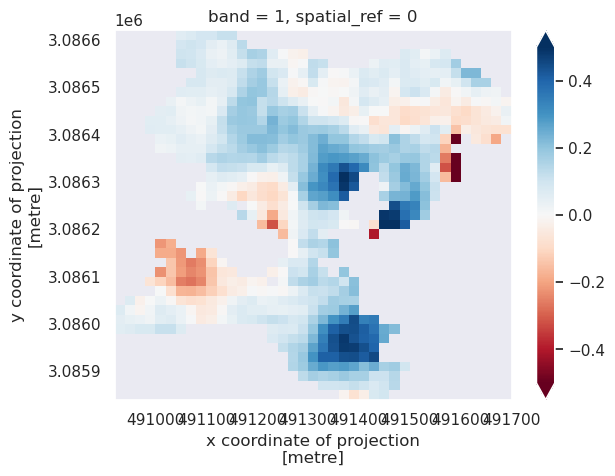

In [41]:
(dem_ew_moving - ew_moving).plot(vmin=-0.5, vmax=0.5, cmap='RdBu')

<Axes: ylabel='Count'>

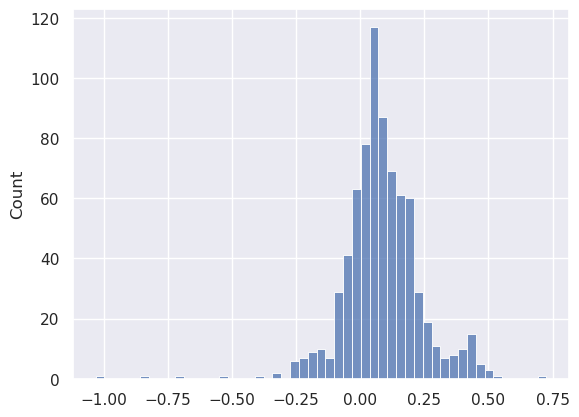

In [42]:
f, ax = plt.subplots()
sns.histplot((dem_ew_moving - ew_moving).values.ravel())

In [43]:
np.nanstd((dem_ew_moving - ew_moving).values.ravel())

0.1519338141536056

In [113]:
dem_ew_moving.mean()

<xarray.DataArray ()> Size: 8B
array(0.14456832)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [45]:
ew_moving.mean()

<xarray.DataArray ()> Size: 8B
array(0.05995993)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [74]:
calculate_r_squared(dem_ew_moving,  ew_moving)

0.1700208669725679

In [75]:
calculate_rmse(dem_ew_moving,  ew_moving)

0.1739036033366373